In [6]:
import pandas as pd

In [7]:
file_path = "/Users/yshmbid/Documents/home/github/kosmos/workspace/data/20260429_Data tool_20260429154123801.xlsx"
df = pd.read_excel(file_path, engine="openpyxl")
df_raw = df
df = df[['SUBJ_ID', 'BRND_CD', 'BRND_NM_VER', 'BRND_NM_ECT_YN', 'BRND_NM_ECT_CMNT']]

df['HOSP_ID'] = df['SUBJ_ID'].apply(lambda x: x.split('-')[0] if isinstance(x, str) and '-' in x else x)
df = df[['HOSP_ID'] + [col for col in df.columns if col != 'HOSP_ID']]
df = df.sort_values('HOSP_ID').reset_index(drop=True)
df = df[~df['HOSP_ID'].isin(['test2', 'test3'])]

/opt/anaconda3/envs/skala/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/var/folders/5_/cr0lgx655m7fqg_j4q733qbm0000gn/T/ipykernel_77445/4043840861.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['HOSP_ID'] = df['SUBJ_ID'].apply(lambda x: x.split('-')[0] if isinstance(x, str) and '-' in x else x)


In [8]:
df_raw

,STUDY_OID,STUDY_NAME,LOCATION_CODE,LOCATION_NAME,SUBJ_ID,ICF_DT,RANDOMNO,SUBJ_STATUS,SUBJ_CONFIRM,SUBJ_LOCK,...,MSI_ECT,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT,GENE_ANLY_CNT,SMPL_TYPE,NSG_TCHN_CD,NSG_TCHN_ECT,RMRK_CMNT
0,NaN,[Beta] NCDC TEST 과제,NGS01,NGS report 데이터 추출,test3,2024-08-19,NaN,Screening,N,N,...,NaN,P017,FoundationOne CDx,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,[Beta] NCDC TEST 과제,NGS01,NGS report 데이터 추출,test2,2024-05-29,NaN,Screening,N,N,...,NaN,P002,FoundationOne CDx,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,[Beta] NCDC TEST 과제,NGS01,NGS report 데이터 추출,S032-005,2026-04-22,NaN,Screening,N,N,...,NaN,P007,Oncomine Comprehensive Assay Plus,NaN,NaN,NaN,1.0,1.0,NaN,NaN
3,NaN,[Beta] NCDC TEST 과제,NGS01,NGS report 데이터 추출,S032-004,2025-09-30,NaN,Screening,N,N,...,NaN,NaN,NaN,1.0,S032-004_panel(AUH-SCT1?),NaN,1.0,1.0,NaN,NaN
4,NaN,[Beta] NCDC TEST 과제,NGS01,NGS report 데이터 추출,S032-003,2025-08-05,NaN,Screening,N,N,...,NaN,P016,TSO500 ver2.2,NaN,NaN,NaN,1.0,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,NaN,[Beta] NCDC TEST 과제,NGS01,NGS report 데이터 추출,S001-006,2023-07-27,NaN,Screening,N,N,...,MSS/MSI-L,P012,NaN,1.0,SNUBH Pan_Cancer Ver2,NaN,1.0,1.0,NaN,NaN
1005,NaN,[Beta] NCDC TEST 과제,NGS01,NGS report 데이터 추출,S001-005,2023-07-27,NaN,Screening,N,N,...,MSS/MSI-L,P016,NaN,1.0,TSO500 ver2.2,NaN,1.0,1.0,NaN,NaN
1006,NaN,[Beta] NCDC TEST 과제,NGS01,NGS report 데이터 추출,S001-004,2023-10-20,NaN,Screening,N,N,...,MSS/MSI-L,P016,NaN,1.0,TSO500 ver2.2,NaN,1.0,NaN,NaN,NaN
1007,NaN,[Beta] NCDC TEST 과제,NGS01,NGS report 데이터 추출,S001-002,2023-10-19,NaN,Screening,N,N,...,MSS/MSI-L,P016,NaN,1.0,TSO500 ver2.2,NaN,NaN,NaN,NaN,NaN


In [9]:
df

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
0,S001,S001-001,P008,Oncomine Comprehensive Assay v3,NaN,NaN
1,S001,S001-090,P016,TSO500 ver2.2,NaN,NaN
2,S001,S001-089,P016,TSO500 ver2.2,NaN,NaN
3,S001,S001-087,P016,TSO500 ver2.2,NaN,NaN
4,S001,S001-086,P016,TSO500 ver2.2,NaN,NaN
...,...,...,...,...,...,...
1002,S031,S031-006,P018,ONCOaccuPanel v4.3,NaN,NaN
1003,S032,S032-002,P019,ONCOaccuPanel v4.5,NaN,NaN
1004,S032,S032-003,P016,TSO500 ver2.2,NaN,NaN
1005,S032,S032-004,NaN,NaN,1.0,S032-004_panel(AUH-SCT1?)


In [10]:
brnd_cd_y = df[df['BRND_CD'].notna()]
brnd_cd_n = df[df['BRND_CD'].isna()]

brnd_cd_y_c1 = brnd_cd_y[brnd_cd_y['BRND_NM_VER'].notna()]
brnd_cd_y_c2 = brnd_cd_y[brnd_cd_y['BRND_NM_VER'].isna()]

brnd_cd_y_c1['hosp_brnd_cd'] = brnd_cd_y_c1['HOSP_ID'] + '_' + brnd_cd_y_c1['BRND_CD']
brnd_cd_y_c1 = brnd_cd_y_c1[['hosp_brnd_cd'] + [col for col in brnd_cd_y_c1.columns if col != 'hosp_brnd_cd']]

brnd_cd_y_c2['hosp_brnd_cd'] = brnd_cd_y_c2['HOSP_ID'] + '_' + brnd_cd_y_c2['BRND_CD']
brnd_cd_y_c2 = brnd_cd_y_c2[['hosp_brnd_cd'] + [col for col in brnd_cd_y_c2.columns if col != 'hosp_brnd_cd']]

hosp_brnd_ver_dict = brnd_cd_y_c1.groupby(['HOSP_ID', 'BRND_CD'])['BRND_NM_VER'].apply(lambda x: list(set(x))).to_dict()
hosp_brnd_ver_dict = {f"{k[0]}_{k[1]}": v for k, v in hosp_brnd_ver_dict.items()}

/var/folders/5_/cr0lgx655m7fqg_j4q733qbm0000gn/T/ipykernel_77445/726540781.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brnd_cd_y_c1['hosp_brnd_cd'] = brnd_cd_y_c1['HOSP_ID'] + '_' + brnd_cd_y_c1['BRND_CD']
/var/folders/5_/cr0lgx655m7fqg_j4q733qbm0000gn/T/ipykernel_77445/726540781.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brnd_cd_y_c2['hosp_brnd_cd'] = brnd_cd_y_c2['HOSP_ID'] + '_' + brnd_cd_y_c2['BRND_CD']


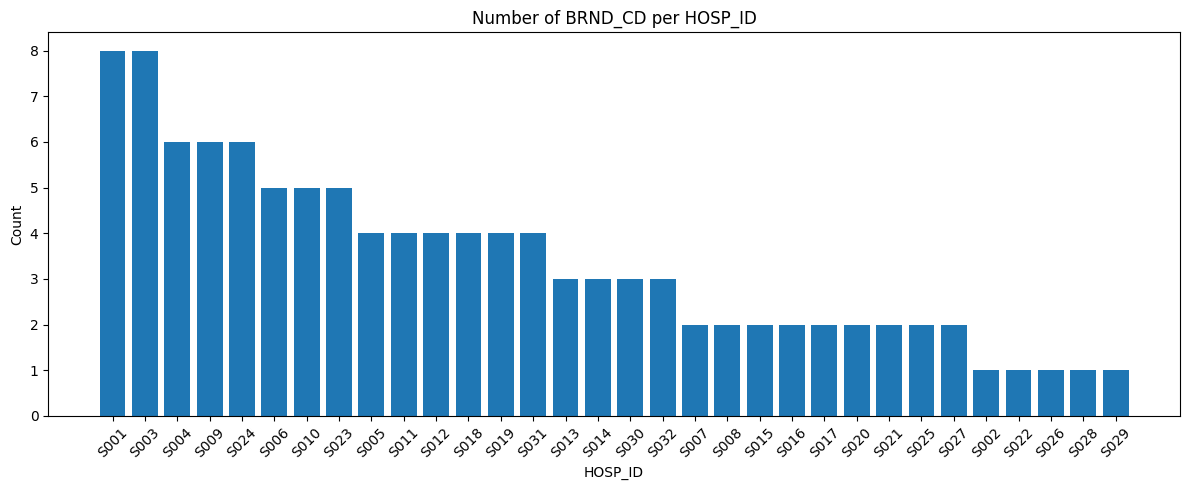

In [11]:
from collections import Counter
import matplotlib.pyplot as plt

hosp_counts = Counter(k.split('_')[0] for k in hosp_brnd_ver_dict.keys())
hosp_counts_sorted = dict(sorted(hosp_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(12, 5))
plt.bar(hosp_counts_sorted.keys(), hosp_counts_sorted.values())
plt.xlabel('HOSP_ID')
plt.ylabel('Count')
plt.title('Number of BRND_CD per HOSP_ID')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
brnd_ver_dict = brnd_cd_y_c1.groupby('BRND_CD')['BRND_NM_VER'].apply(lambda x: list(set(x))).to_dict()

In [13]:
brnd_cd_y_c2_v1 = brnd_cd_y_c2[brnd_cd_y_c2['BRND_NM_ECT_CMNT'].notna()]
brnd_cd_y_c2_v2 = brnd_cd_y_c2[brnd_cd_y_c2['BRND_NM_ECT_CMNT'].isna()]

hosp_brnd_cmnt_dict = brnd_cd_y_c2_v1.groupby(['HOSP_ID', 'BRND_CD'])['BRND_NM_ECT_CMNT'].apply(lambda x: list(set(x))).to_dict()
hosp_brnd_cmnt_dict = {f"{k[0]}_{k[1]}": v for k, v in hosp_brnd_cmnt_dict.items()}

In [14]:
hosp_brnd_cmnt_dict

{'S001_P012': ['SNUBH Pan_Cancer Ver2'],
 'S001_P016': ['TSO500 ver2.2'],
 'S002_P007': ['Oncomine Comprehensive Assay Plus'],
 'S003_P016': ['TSO500 ver2.2'],
 'S003_P017': ['CancerSCAN v2.2'],
 'S003_P034': ['CancerSCAN v3.1'],
 'S004_P016': ['TSO500 ver2.2'],
 'S004_P017': ['CancerSCAN v2.2'],
 'S005_P009': ['OncoPanel AMC v4.5'],
 'S005_P013': ['Solid Tumor Panel II(TMB/MSI)(RNA included)'],
 'S005_P016': ['TSO500 ver2.2'],
 'S006_P009': ['OncoPanel AMC v4.5'],
 'S006_P016': ['TSO500 ver2.2'],
 'S006_P032': ['OncoPanel AMC v4.3'],
 'S007_P007': ['Oncomine Comprehensive Assay Plus'],
 'S009_P003': ['CancerSCAN compact'],
 'S009_P034': ['CancerSCAN v3.1'],
 'S010_P015': ['TruSight Tumor 170 panel'],
 'S010_P016': ['TSO500 ver2.2'],
 'S011_P016': ['TSO500 ver2.2'],
 'S012_P007': ['Oncomine Comprehensive Assay Plus'],
 'S013_P013': ['Solid Tumor Panel II(TMB/MSI)(RNA included)'],
 'S016_P016': ['TSO500 ver2.2'],
 'S018_P018': ['ONCOaccuPanel v4.3'],
 'S020_P007': ['Oncomine Comprehensi

In [15]:
brnd_cd_n_c1 = brnd_cd_n[brnd_cd_n['BRND_NM_VER'].isna()]
brnd_cd_n_c2 =brnd_cd_n[brnd_cd_n['BRND_NM_VER'].notna()]

for idx, row in brnd_cd_n_c2.iterrows():
    ver = row['BRND_NM_VER']
    for key, values in brnd_ver_dict.items():
        if ver in values:
            print(f"idx {idx}: SUBJ_ID={row['SUBJ_ID']}, BRND_NM_VER='{ver}' -> {key}")

In [16]:
panel_table_path1 = "/Users/yshmbid/Documents/home/github/kosmos/workspace/data/sheet1.csv"
panel_table_path2 = "/Users/yshmbid/Documents/home/github/kosmos/workspace/data/sheet2.csv"
panel_table_path3 = "/Users/yshmbid/Documents/home/github/kosmos/workspace/data/sheet3.csv"

panel_table_1 = pd.read_csv(panel_table_path1, header=6).iloc[:, 1:]
#panel_table_2 = pd.read_csv(panel_table_path2)
panel_table_3 = pd.read_csv(panel_table_path3)

In [17]:
panel_table_3

,panel_cd,panel_nm,site_cd,site_nm
0,P001,AlphaLiquid®100(v2),S003,고대안암병원
1,P001,AlphaLiquid®100(v2),S016,고려대학교 구로병원
2,P001,AlphaLiquid®100(v2),S017,계명대동산병원
3,P001,AlphaLiquid®100(v2),S012,서울성모병원
4,P002,AUH-SCT1,S011,아주대병원
...,...,...,...,...
87,P034,CancerSCAN v3.1,S009,강북삼성병원
88,P034,CancerSCAN v3.1,S025,분당차병원
89,P034,CancerSCAN v3.1,S031,화순전남대학교병원
90,P035,KUMC cancer Panel v1.1,S003,고대안암병원


In [18]:
hosp_brnd_ver_df = pd.DataFrame([
    {
        "hosp_brnd_cd_dict": key,
        "panel_nm_dict": value[0] if isinstance(value, list) and len(value) > 0 else None
        #"dict_yn": "y"
    }
    for key, value in hosp_brnd_ver_dict.items()
])

In [19]:
hosp_brnd_ver_df

,hosp_brnd_cd_dict,panel_nm_dict
0,S001_P004,FoundationOne CDx
1,S001_P008,Oncomine Comprehensive Assay v3
2,S001_P009,OncoPanel AMC v4.5
3,S001_P011,SNUBH Pan_Cancer Ver1
4,S001_P012,SNUBH Pan_Cancer Ver2
...,...,...
103,S031_P018,ONCOaccuPanel v4.3
104,S031_P034,CancerSCAN v3.1
105,S032_P007,Oncomine Comprehensive Assay Plus
106,S032_P016,TSO500 ver2.2


In [20]:
df

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT
0,S001,S001-001,P008,Oncomine Comprehensive Assay v3,NaN,NaN
1,S001,S001-090,P016,TSO500 ver2.2,NaN,NaN
2,S001,S001-089,P016,TSO500 ver2.2,NaN,NaN
3,S001,S001-087,P016,TSO500 ver2.2,NaN,NaN
4,S001,S001-086,P016,TSO500 ver2.2,NaN,NaN
...,...,...,...,...,...,...
1002,S031,S031-006,P018,ONCOaccuPanel v4.3,NaN,NaN
1003,S032,S032-002,P019,ONCOaccuPanel v4.5,NaN,NaN
1004,S032,S032-003,P016,TSO500 ver2.2,NaN,NaN
1005,S032,S032-004,NaN,NaN,1.0,S032-004_panel(AUH-SCT1?)


In [21]:
df['BRND_CD'].value_counts()

BRND_CD
P016    326
P007    161
P009    109
P018     47
P001     32
P034     28
P013     25
P024     23
P008     20
P019     18
P027     14
P006     12
P032     12
P012     10
P036      7
P023      7
P020      6
P014      5
P003      5
P005      4
P021      4
P031      3
P017      3
P035      3
P022      3
P002      3
P004      3
P028      2
P025      1
P033      1
P010      1
P015      1
P026      1
P011      1
P030      1
P029      1
Name: count, dtype: int64

In [22]:
df['HOSP_ID'].value_counts()

HOSP_ID
S006    120
S001    115
S003    113
S010     91
S002     65
S007     49
S004     48
S012     44
S016     31
S011     28
S023     26
S031     25
S024     24
S020     22
S005     22
S009     20
S018     19
S027     17
S008     17
S014     14
S013     14
S030     12
S021     11
S026      8
S015      8
S025      8
S019      8
S028      8
S017      7
S022      5
S029      4
S032      4
Name: count, dtype: int64

In [23]:
df['hosp_brnd_cd'] = df['HOSP_ID'] + '_' + df['BRND_CD']

In [24]:
df

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT,hosp_brnd_cd
0,S001,S001-001,P008,Oncomine Comprehensive Assay v3,NaN,NaN,S001_P008
1,S001,S001-090,P016,TSO500 ver2.2,NaN,NaN,S001_P016
2,S001,S001-089,P016,TSO500 ver2.2,NaN,NaN,S001_P016
3,S001,S001-087,P016,TSO500 ver2.2,NaN,NaN,S001_P016
4,S001,S001-086,P016,TSO500 ver2.2,NaN,NaN,S001_P016
...,...,...,...,...,...,...,...
1002,S031,S031-006,P018,ONCOaccuPanel v4.3,NaN,NaN,S031_P018
1003,S032,S032-002,P019,ONCOaccuPanel v4.5,NaN,NaN,S032_P019
1004,S032,S032-003,P016,TSO500 ver2.2,NaN,NaN,S032_P016
1005,S032,S032-004,NaN,NaN,1.0,S032-004_panel(AUH-SCT1?),NaN


In [25]:
txt_path = "/Users/yshmbid/Documents/home/github/kosmos/workspace/data/maf_files_0430.txt"

with open(txt_path, "r", encoding="utf-8") as f:
    maf_files = [line.strip() for line in f if line.strip()]

In [26]:
maf_df = pd.DataFrame({
    "HOSP_ID": [file_name[:4] for file_name in maf_files],
    "file_name": maf_files
})

In [27]:
maf_df

,HOSP_ID,file_name
0,S001,S001-002.maf
1,S001,S001-004.maf
2,S001,S001-005.maf
3,S001,S001-006.maf
4,S001,S001-007.maf
...,...,...
923,S032,S032-001.maf
924,S032,S032-002.maf
925,S032,S032-003.maf
926,S032,S032-004.maf


In [28]:
df

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT,hosp_brnd_cd
0,S001,S001-001,P008,Oncomine Comprehensive Assay v3,NaN,NaN,S001_P008
1,S001,S001-090,P016,TSO500 ver2.2,NaN,NaN,S001_P016
2,S001,S001-089,P016,TSO500 ver2.2,NaN,NaN,S001_P016
3,S001,S001-087,P016,TSO500 ver2.2,NaN,NaN,S001_P016
4,S001,S001-086,P016,TSO500 ver2.2,NaN,NaN,S001_P016
...,...,...,...,...,...,...,...
1002,S031,S031-006,P018,ONCOaccuPanel v4.3,NaN,NaN,S031_P018
1003,S032,S032-002,P019,ONCOaccuPanel v4.5,NaN,NaN,S032_P019
1004,S032,S032-003,P016,TSO500 ver2.2,NaN,NaN,S032_P016
1005,S032,S032-004,NaN,NaN,1.0,S032-004_panel(AUH-SCT1?),NaN


In [29]:
panel_table_3['hosp_brnd_cd'] = panel_table_3['site_cd'] + '_' + panel_table_3['panel_cd']

In [30]:
panel_table_3

,panel_cd,panel_nm,site_cd,site_nm,hosp_brnd_cd
0,P001,AlphaLiquid®100(v2),S003,고대안암병원,S003_P001
1,P001,AlphaLiquid®100(v2),S016,고려대학교 구로병원,S016_P001
2,P001,AlphaLiquid®100(v2),S017,계명대동산병원,S017_P001
3,P001,AlphaLiquid®100(v2),S012,서울성모병원,S012_P001
4,P002,AUH-SCT1,S011,아주대병원,S011_P002
...,...,...,...,...,...
87,P034,CancerSCAN v3.1,S009,강북삼성병원,S009_P034
88,P034,CancerSCAN v3.1,S025,분당차병원,S025_P034
89,P034,CancerSCAN v3.1,S031,화순전남대학교병원,S031_P034
90,P035,KUMC cancer Panel v1.1,S003,고대안암병원,S003_P035


In [31]:
import numpy as np

df["ecrf_annot"] = np.where(df["HOSP_ID"].notna() & df["BRND_CD"].notna(), "y", "n")

In [32]:
df['ecrf_annot'].value_counts()

ecrf_annot
y    903
n    104
Name: count, dtype: int64

In [33]:
df

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT,hosp_brnd_cd,ecrf_annot
0,S001,S001-001,P008,Oncomine Comprehensive Assay v3,NaN,NaN,S001_P008,y
1,S001,S001-090,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y
2,S001,S001-089,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y
3,S001,S001-087,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y
4,S001,S001-086,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y
...,...,...,...,...,...,...,...,...
1002,S031,S031-006,P018,ONCOaccuPanel v4.3,NaN,NaN,S031_P018,y
1003,S032,S032-002,P019,ONCOaccuPanel v4.5,NaN,NaN,S032_P019,y
1004,S032,S032-003,P016,TSO500 ver2.2,NaN,NaN,S032_P016,y
1005,S032,S032-004,NaN,NaN,1.0,S032-004_panel(AUH-SCT1?),NaN,n


In [34]:
# panel_table_3의 hosp_brnd_cd 값을 리스트/집합으로 준비
panel_hosp_brnd_cd_list = panel_table_3["hosp_brnd_cd"].dropna().tolist()

# df의 ecrf_annot == "y"인 행 중에서
# hosp_brnd_cd가 panel_hosp_brnd_cd_list 안에 있으면 panel_annot = "y"
# 아니면 "n"

df["panel_annot"] = np.where(
    (df["ecrf_annot"].eq("y")) &
    (df["hosp_brnd_cd"].isin(panel_hosp_brnd_cd_list)),
    "y",
    "n"
)

In [35]:
df['panel_annot'].value_counts()

panel_annot
y    849
n    158
Name: count, dtype: int64

In [36]:
maf_df

,HOSP_ID,file_name
0,S001,S001-002.maf
1,S001,S001-004.maf
2,S001,S001-005.maf
3,S001,S001-006.maf
4,S001,S001-007.maf
...,...,...
923,S032,S032-001.maf
924,S032,S032-002.maf
925,S032,S032-003.maf
926,S032,S032-004.maf


In [37]:
pattern = r"^S\d{3}[-_]\d{3}\.maf$"

maf_df.loc[
    ~maf_df["file_name"].astype(str).str.match(pattern),
    ["file_name"]
]["file_name"].tolist()

['S001-110_S001-110.maf',
 'S002-013-snvindel.maf',
 'S002-016-snvindel.maf',
 'S002-017-snvindel.maf',
 'S002-018-snvindel.maf',
 'S002-019-snvindel.maf',
 'S002-021-snvindel.maf',
 'S002-022-snvindel.maf',
 'S002-024-snvindel.maf',
 'S002-025-snvindel.maf',
 'S002-026-snvindel.maf',
 'S002-027-snvindel.maf',
 'S003-018-snvindel.maf',
 'S003-021-snvindel.maf',
 'S003-023-snvindel.maf',
 'S003-026-snvindel.maf',
 'S003-027-snvindel.maf',
 'S003-029-snvindel.maf',
 'S003-037-snvindel.maf',
 'S003-038-snvindel.maf',
 'S003-039-snvindel.maf',
 'S003-040-snvindel.maf',
 'S003-042-snvindel.maf',
 'S003-046-snvindel.maf',
 'S003-048-CNV.maf',
 'S003-050-cnv.maf',
 'S003-050-snv.maf',
 'S003-051-cnv.maf',
 'S003-051-snv.maf',
 'S003-052-snv.maf',
 'S003-053-CNV.maf',
 'S003-053-SNV.maf',
 'S003-054-cnv.maf',
 'S003-054-snv.maf',
 'S003-055-cnv.maf',
 'S003-055-snv.maf',
 'S003-056-SNV.maf',
 'S003-056-cnv.maf',
 'S003-058-SNV-INDEL.maf',
 'S003-058-cnv.maf',
 'S003-058-snv.maf',
 'S003-059-CN

In [38]:
maf_df["SUBJ_ID"] = maf_df["file_name"].astype(str).str[:8]

In [39]:
maf_df

,HOSP_ID,file_name,SUBJ_ID
0,S001,S001-002.maf,S001-002
1,S001,S001-004.maf,S001-004
2,S001,S001-005.maf,S001-005
3,S001,S001-006.maf,S001-006
4,S001,S001-007.maf,S001-007
...,...,...,...
923,S032,S032-001.maf,S032-001
924,S032,S032-002.maf,S032-002
925,S032,S032-003.maf,S032-003
926,S032,S032-004.maf,S032-004


In [40]:
maf_samples = list(set(maf_df['SUBJ_ID'].tolist()))

In [41]:
len(maf_samples)

855

In [42]:
df

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT,hosp_brnd_cd,ecrf_annot,panel_annot
0,S001,S001-001,P008,Oncomine Comprehensive Assay v3,NaN,NaN,S001_P008,y,y
1,S001,S001-090,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y
2,S001,S001-089,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y
3,S001,S001-087,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y
4,S001,S001-086,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y
...,...,...,...,...,...,...,...,...,...
1002,S031,S031-006,P018,ONCOaccuPanel v4.3,NaN,NaN,S031_P018,y,y
1003,S032,S032-002,P019,ONCOaccuPanel v4.5,NaN,NaN,S032_P019,y,n
1004,S032,S032-003,P016,TSO500 ver2.2,NaN,NaN,S032_P016,y,n
1005,S032,S032-004,NaN,NaN,1.0,S032-004_panel(AUH-SCT1?),NaN,n,n


In [43]:
df["exist_in_maf"] = np.where(
    df["SUBJ_ID"].isin(maf_samples),
    "y",
    "n"
)

In [44]:
df[
    (df["ecrf_annot"].eq("y")) &
    (df["panel_annot"].eq("y")) &
    (df["exist_in_maf"].eq("y"))
]

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT,hosp_brnd_cd,ecrf_annot,panel_annot,exist_in_maf
1,S001,S001-090,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y,y
2,S001,S001-089,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y,y
3,S001,S001-087,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y,y
4,S001,S001-086,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y,y
5,S001,S001-085,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y,y
...,...,...,...,...,...,...,...,...,...,...
997,S031,S031-007,P018,ONCOaccuPanel v4.3,NaN,NaN,S031_P018,y,y,y
998,S031,S031-008,P018,ONCOaccuPanel v4.3,NaN,NaN,S031_P018,y,y,y
1000,S031,S031-010,P018,ONCOaccuPanel v4.3,NaN,NaN,S031_P018,y,y,y
1001,S031,S031-011,P018,ONCOaccuPanel v4.3,NaN,NaN,S031_P018,y,y,y


In [45]:
maf_df

,HOSP_ID,file_name,SUBJ_ID
0,S001,S001-002.maf,S001-002
1,S001,S001-004.maf,S001-004
2,S001,S001-005.maf,S001-005
3,S001,S001-006.maf,S001-006
4,S001,S001-007.maf,S001-007
...,...,...,...
923,S032,S032-001.maf,S032-001
924,S032,S032-002.maf,S032-002
925,S032,S032-003.maf,S032-003
926,S032,S032-004.maf,S032-004


In [46]:
df

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT,hosp_brnd_cd,ecrf_annot,panel_annot,exist_in_maf
0,S001,S001-001,P008,Oncomine Comprehensive Assay v3,NaN,NaN,S001_P008,y,y,n
1,S001,S001-090,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y,y
2,S001,S001-089,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y,y
3,S001,S001-087,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y,y
4,S001,S001-086,P016,TSO500 ver2.2,NaN,NaN,S001_P016,y,y,y
...,...,...,...,...,...,...,...,...,...,...
1002,S031,S031-006,P018,ONCOaccuPanel v4.3,NaN,NaN,S031_P018,y,y,y
1003,S032,S032-002,P019,ONCOaccuPanel v4.5,NaN,NaN,S032_P019,y,n,y
1004,S032,S032-003,P016,TSO500 ver2.2,NaN,NaN,S032_P016,y,n,y
1005,S032,S032-004,NaN,NaN,1.0,S032-004_panel(AUH-SCT1?),NaN,n,n,y


In [47]:
maf_df['BRND_NM_VER'] = maf_df['SUBJ_ID'].str.replace('_', '-').map(
    df.assign(
        BRND_NM_VER=df['BRND_NM_VER'].fillna(df['BRND_NM_ECT_CMNT'])
    ).groupby('SUBJ_ID')['BRND_NM_VER'].apply(list)
)

In [48]:
maf_df['BRND_NM_VER']

0                          [TSO500 ver2.2]
1                          [TSO500 ver2.2]
2                          [TSO500 ver2.2]
3                  [SNUBH Pan_Cancer Ver2]
4                          [TSO500 ver2.2]
                      ...                 
923                                    NaN
924                   [ONCOaccuPanel v4.5]
925                        [TSO500 ver2.2]
926            [S032-004_panel(AUH-SCT1?)]
927    [Oncomine Comprehensive Assay Plus]
Name: BRND_NM_VER, Length: 928, dtype: object

In [49]:
nan_sids = maf_df[maf_df['BRND_NM_VER'].isna()]['SUBJ_ID'].tolist()

In [50]:
len(nan_sids)

37

In [51]:
nan_sids_fixed = [s.replace('_', '-') for s in nan_sids]
df[df['SUBJ_ID'].isin(nan_sids_fixed)]

,HOSP_ID,SUBJ_ID,BRND_CD,BRND_NM_VER,BRND_NM_ECT_YN,BRND_NM_ECT_CMNT,hosp_brnd_cd,ecrf_annot,panel_annot,exist_in_maf


In [52]:
nan_sids

['S001-062',
 'S001-068',
 'S001-074',
 'S001-082',
 'S001-088',
 'S001-092',
 'S003-019',
 'S003-051',
 'S003-051',
 'S004-044',
 'S004-044',
 'S006-024',
 'S006-084',
 'S006-102',
 'S006-111',
 'S007-024',
 'S008-011',
 'S008-015',
 'S010-039',
 'S010-063',
 'S010-073',
 'S011-011',
 'S011-013',
 'S012-022',
 'S012-026',
 'S012-037',
 'S014-001',
 'S018-022',
 'S018-022',
 'S018-022',
 'S018-022',
 'S023-011',
 'S024-006',
 'S027-014',
 'S031-012',
 'S031-025',
 'S032-001']

In [53]:
maf_df['BRND_NM_VER'] = maf_df['BRND_NM_VER'].apply(
    lambda x: list(dict.fromkeys(x)) if isinstance(x, list) else x
)

In [54]:
maf_df[maf_df['BRND_NM_VER'].apply(lambda x: isinstance(x, list) and len(x) >= 2)]

,HOSP_ID,file_name,SUBJ_ID,BRND_NM_VER
26,S001,S001-031.maf,S001-031,"[TSO500 ver2.2, FoundationOne CDx]"
187,S003,S003-046-snvindel.maf,S003-046,"[CancerSCAN v3.1, AlphaLiquid®100(v2)]"
219,S003,S003-066-CNV.maf,S003-066,"[AlphaLiquid®100(v2), TSO500 ver2.2]"
220,S003,S003-066-SNV.maf,S003-066,"[AlphaLiquid®100(v2), TSO500 ver2.2]"
228,S003,S003-075.maf,S003-075,"[AlphaLiquid®100(v2), CancerSCAN v3.1]"
233,S003,S003-078.maf,S003-078,"[CancerSCAN v3.1, AlphaLiquid®100(v2)]"
270,S004,S004-002.maf,S004-002,"[CancerSCAN v2.2, CancerSCAN v2.1, GENOME INSI..."
274,S004,S004-005.maf,S004-005,"[TSO500 ver2.2, FoundationOne Liquid CDx]"
283,S004,S004-010.maf,S004-010,"[TSO500 ver2.2, FoundationOne Liquid CDx]"
488,S007,S007-014-snvindel.maf,S007-014,"[S007(OCA)_panel, Oncomine Comprehensive Assay..."


In [55]:
maf_df.to_csv("/Users/yshmbid/Documents/home/github/kosmos/workspace/data/maf_0511_revised.csv", index=False)

In [56]:
nan_sids = maf_df[maf_df['BRND_NM_VER'].isna()]['SUBJ_ID'].tolist()

In [57]:
len(nan_sids)

37

In [59]:
df.to_csv("/Users/yshmbid/Documents/home/github/kosmos/workspace/data/datatool.csv", index=False)